Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries Loaded.")

Libraries Loaded.


Data Loading

In [2]:
# Load the data generated in the previous notebook
df_final = pd.read_csv('processed_ev_data.csv')

# Ensure timestamp is datetime (CSV loading often resets it to string)
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'])

print(f"Data Loaded. Shape: {df_final.shape}")

Data Loaded. Shape: (9588, 18)


Splitting


In [3]:
# Define features and target
feature_cols = [
    'traffic_volume', 'temp', 'precip', 'wind_spd',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h'
]
target_col = 'total_load_kwh'

# 80-20 Chronological Split
split_point = int(len(df_final) * 0.8)

X = df_final[feature_cols]
y = df_final[target_col]

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]
test_dates = df_final['timestamp'].iloc[split_point:]

print(f"Train Size: {len(X_train)} | Test Size: {len(X_test)}")

Train Size: 7670 | Test Size: 1918


Scaling


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DF for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Data Scaled.")

Data Scaled.


Random Forest

In [5]:
# Initialize and Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE: {rmse_rf:.2f} kWh")

Random Forest RMSE: 24.27 kWh


Prophet

In [6]:
# Prepare format for Prophet
df_prophet = df_final[['timestamp', 'total_load_kwh', 'temp', 'traffic_volume']].copy()
df_prophet.rename(columns={'timestamp': 'ds', 'total_load_kwh': 'y'}, inplace=True)

# Split (Same index as RF)
train_prophet = df_prophet.iloc[:split_point]
test_prophet = df_prophet.iloc[split_point:]

# Train
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
m.add_regressor('temp')
m.add_regressor('traffic_volume')
m.fit(train_prophet)

# Predict
future = test_prophet.drop(columns=['y'])
forecast = m.predict(future)
y_pred_prophet = forecast['yhat'].values

# Evaluate
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], y_pred_prophet))
print(f"Prophet RMSE: {rmse_prophet:.2f} kWh")

19:21:05 - cmdstanpy - INFO - Chain [1] start processing
19:21:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 27.82 kWh


Comparision

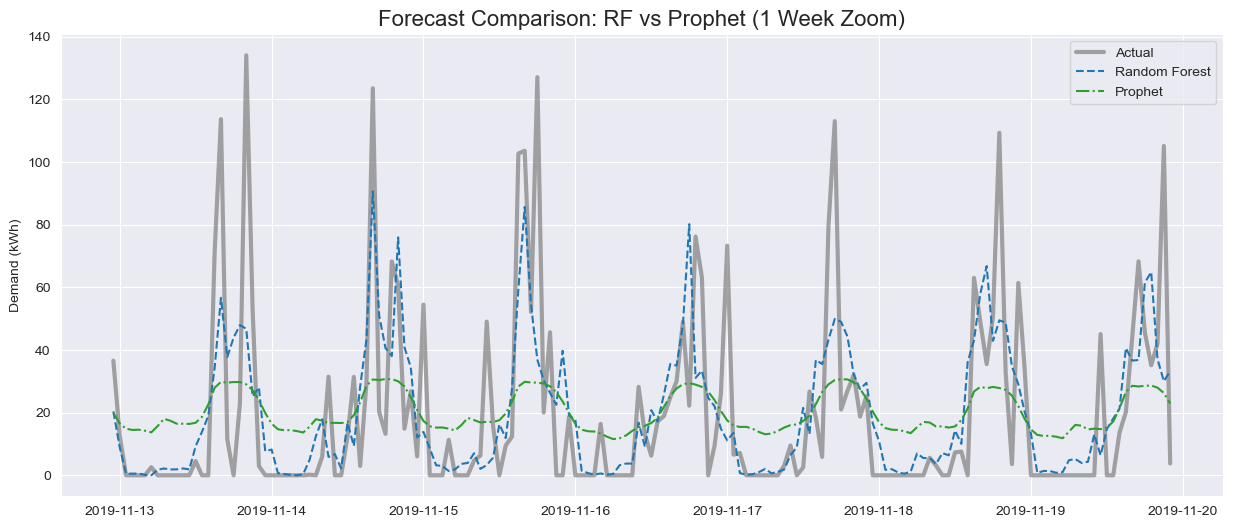

In [7]:
# Combine results
comparison_df = pd.DataFrame({
    'timestamp': test_dates,
    'Actual': y_test.values,
    'Random Forest': y_pred_rf,
    'Prophet': y_pred_prophet
}).set_index('timestamp')

# Plot 1 week zoom
subset = comparison_df.iloc[:168] # First 168 hours

plt.figure(figsize=(15, 6))
plt.plot(subset.index, subset['Actual'], label='Actual', color='gray', alpha=0.7, linewidth=3)
plt.plot(subset.index, subset['Random Forest'], label='Random Forest', color='#1f77b4', linestyle='--')
plt.plot(subset.index, subset['Prophet'], label='Prophet', color='#2ca02c', linestyle='-.')

plt.title('Forecast Comparison: RF vs Prophet (1 Week Zoom)', fontsize=16)
plt.ylabel('Demand (kWh)')
plt.legend()
plt.show()

Feature importance


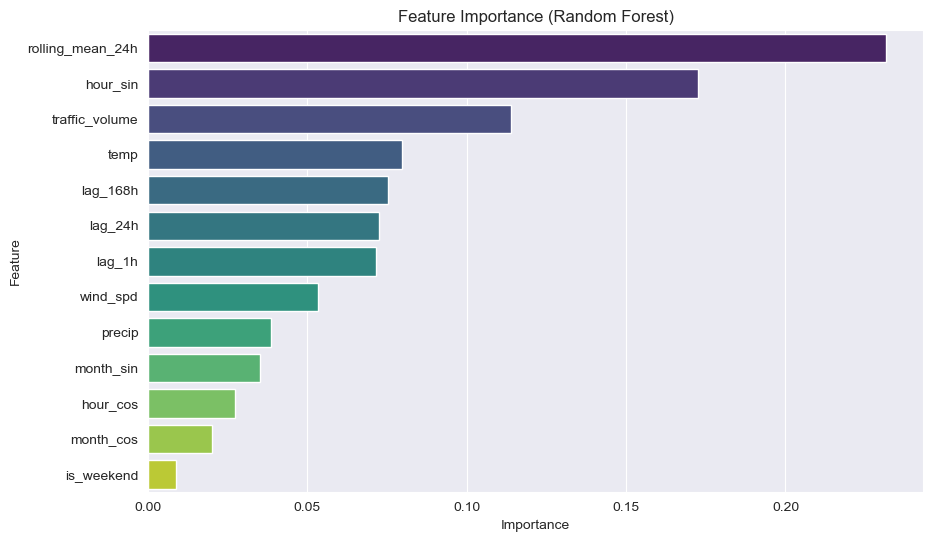

In [8]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

Save data for dashboard


In [9]:
# --- EXPORT FOR TABLEAU ---
# We save the comparison dataframe (Actual vs Predicted)
# Reset index to make 'timestamp' a column
tableau_export = comparison_df.reset_index()

# Save to CSV
tableau_export.to_csv('tableau_forecast_results.csv', index=False)
print("File saved: 'tableau_forecast_results.csv'. Use this for the Forecast Chart in Tableau.")

File saved: 'tableau_forecast_results.csv'. Use this for the Forecast Chart in Tableau.
